# The 4x3 grid world with gymnasium

- This notebook mirrors the `L12_01_gridworld_4x3` notebook cell-by-cell
- Uses a `gymnasium.Env` subclass for the same 4x3 grid world
- The environment exposes `P[s][a]` (FrozenLake convention) for planning, and
  `step()` for model-free learning
- The pedagogical arc:
  - Build the env
  - Solve it with full knowledge
  - Learn without a model, as in the from-scratch version
- The only difference from the from-scratch version is the API:
  - States are integer IDs (0-10) instead of `(col, row)` tuples
  - Actions are integer IDs (0-3) instead of strings
  - `gymnasium` calls `reset()` and `step()` instead of direct model access

In [ ]:
%load_ext autoreload
%autoreload 2

import logging


In [ ]:
import helpers.hintrospection as hintros
import helpers.hnotebook as hnotebook

import L12_02_gridworld_4x3_gymnasium_utils as utils

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
_LOG = logging.getLogger(__name__)
utils.init_loggers(_LOG)

# Convert `display` into `print()` when running outside IPython.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

# Part 1: Building the Grid World Environment (Gymnasium)

## Cell 1.1: The 4x3 grid and its states

**Goal**
- Same layout as the from-scratch version: 4x3 grid with START, +1, -1,
  WALL
- This time, states are `gym.spaces.Discrete(11)` and actions are
  `gym.spaces.Discrete(4)`
- The grid world is fully observable (the agent sees its state ID) but
  stochastic (actions do not always succeed)

**Implementation** `utils.cell1_1_show_grid()`

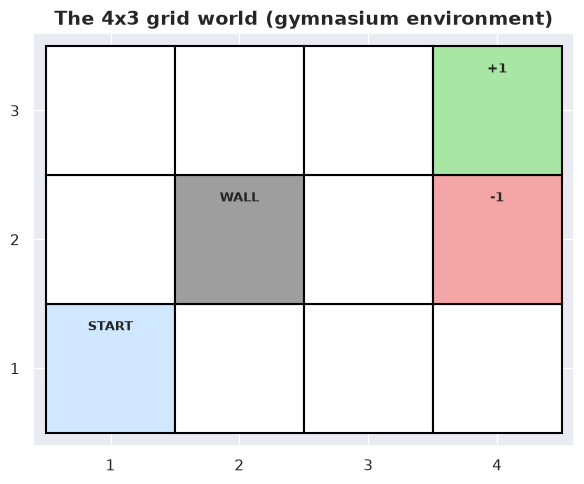

observation_space: Discrete(11)
action_space: Discrete(4)
n_states=11
state id -> cell mapping:
  0 -> (1, 1)
  1 -> (2, 1)
  2 -> (3, 1)
  3 -> (4, 1)
  4 -> (1, 2)
  5 -> (3, 2)
  6 -> (4, 2)
  7 -> (1, 3)
  8 -> (2, 3)
  9 -> (3, 3)
  10 -> (4, 3)
terminal ids: [6, 10]


In [23]:
# Draw the grid and print the gymnasium observation / action spaces.
utils.cell1_1_show_grid()

- The environment has 11 reachable states (12 cells minus 1 wall)
- Two states are terminal: reaching either ends the episode
- State IDs 0-10 map to the same `(col, row)` cells

## Cell 1.2: Stochastic action model

**Goal**
- See the stochastic slip model through the gymnasium `env.P[s][a]`
  interface
- Understand how the intended action and perpendicular slips share
  probability mass

**Description**
- Inputs
  - `action`: which action to inspect
  - `p_intended`: probability the intended action succeeds

- Panels
  - `Grid`: highlighted state, with arrow thickness encoding outcome
    probability
  - `Comments`: current parameter values and computed outcome
    probabilities

In [24]:
# Show how an intended action spreads probability mass through env.P.
utils.cell1_2_stochastic_action()

**Guided usage**
- Raise `p_intended` toward `1.0`
  - Observe the intended-direction arrow thickens while the 2
    perpendicular arrows thin out: the intended action and
    perpendicular slips share probability mass

**Implementation** `utils.cell1_2_stochastic_action()`

In [ ]:
hintros.print_obj_info(utils.cell1_2_stochastic_action)

## Cell 1.3: Transition model from env.P

**Goal**
- See how `env.P[s][a]` exposes the transition model as `(prob, s',
  reward, terminated)` tuples
- Understand that planning algorithms read this dict while Q-learning
  uses `step()`

**Description**
- Inputs
  - `state`: which state to inspect
  - `action`: which action to inspect

- Panels
  - `Transition heatmap`: probability distribution over next states
    for the selected (state, action)
  - `Transition table`: each outcome with probability, reward, and
    terminal flag

In [25]:
# Display the explicit transition row from env.P for a chosen (state, action).
utils.cell1_3_transition_table()

**Guided usage**
- Select a state next to a terminal, with the action pointing into it
  - Observe the outcome row's `terminated` flag is set for the terminal
    next state, and its reward matches the terminal's value

**Implementation** `utils.cell1_3_transition_table()`

In [ ]:
hintros.print_obj_info(utils.cell1_3_transition_table)

## Cell 1.4: Rewards and episode returns

**Goal**
- Define the reward structure and connect per-step rewards to
  discounted return
- See a sample trajectory rolled out via `env.step()`

**Description**
- Inputs
  - `r_step`: living reward per step
  - `gamma`: discount factor
  - `seed`: trajectory seed

- Panels
  - `Rewards and trajectory`: per-cell living rewards, with a
    sample path from START
  - `Comments`: the discounted-return computation and step-by-step
    rewards

In [26]:
# Show per-cell rewards and the discounted return of a sample trajectory.
utils.cell1_4_rewards_and_returns()

**Guided usage**
- Resample with a different `seed`
  - Observe `env.step()` produces a different path each time, and the
    Comments panel's discounted return changes with it

**Implementation** `utils.cell1_4_rewards_and_returns()`

In [ ]:
hintros.print_obj_info(utils.cell1_4_rewards_and_returns)

# Part 2: Solving the MDP with Value Iteration

## Cell 2.1: The Bellman equation for one state

**Goal**
- Build intuition for the Bellman update on a single state using
  integer state and action IDs
- See how the Bellman update reads `env.P[s][a]` to compute Q-values

**Description**
- Inputs
  - `state`: which state to inspect the action values for
  - `gamma`: discount factor

- Panels
  - the Q-value of each action at the selected state

In [27]:
# Show the value of each action at one state under converged utilities.
utils.cell2_1_bellman_one_state()

**Guided usage**
- Compare the Q-values across actions at any state
  - Observe the utility of a state is the value of its best action: the
    max is what makes the system nonlinear, requiring iteration

**Implementation** `utils.cell2_1_bellman_one_state()`

In [ ]:
hintros.print_obj_info(utils.cell2_1_bellman_one_state)

## Cell 2.2: Value iteration converging over sweeps

**Goal**
- Watch value iteration converge on the gymnasium `env.P` model
- See utility information propagate backward from the terminals

**Description**
- Inputs
  - `iteration`: value iteration sweep to display
  - `gamma`: discount factor
  - `r_step`: living reward

- Panels
  - the grid's utilities at the selected sweep

In [28]:
# Step through value iteration sweeps and watch utilities converge.
utils.cell2_2_value_iteration()

**Guided usage**
- Step `iteration` forward from 0
  - Observe value propagates backward from the terminals, one ring per
    sweep, and the change per sweep shrinks geometrically

**Implementation** `utils.cell2_2_value_iteration()`

In [ ]:
hintros.print_obj_info(utils.cell2_2_value_iteration)

## Cell 2.3: Extracting the optimal policy

**Goal**
- Turn converged utilities into an actionable policy
- Take the greedy action in every cell

**Description**
- Inputs
  - `r_step`: living reward

- Panels
  - the grid with an arrow per cell pointing toward the greedy action

In [29]:
# Show the greedy policy extracted from converged utilities.
utils.cell2_3_extract_policy()

**Guided usage**
- Make `r_step` a large negative number
  - Observe expensive steps push the agent toward the short risky path
- Make `r_step` close to 0
  - Observe cheap steps let the agent take the long safe route instead

**Implementation** `utils.cell2_3_extract_policy()`

In [ ]:
hintros.print_obj_info(utils.cell2_3_extract_policy)

# Part 3: Solving the MDP with Policy Iteration

## Cell 3.1: Policy evaluation for a fixed policy

**Goal**
- Compute the utility of a fixed policy by solving
  $(I - \gamma P) U = b$
- Read transition probabilities from `env.P[s][a]`

**Description**
- Inputs
  - `policy`: which fixed policy to evaluate
  - `gamma`: discount factor

- Panels
  - the utility of every state under the selected fixed policy

In [30]:
# Evaluate a fixed policy by solving the linear Bellman system.
utils.cell3_1_policy_evaluation()

**Guided usage**
- Select a deliberately bad `policy`
  - Observe it yields low utilities, especially near the `-1`
    terminal: evaluation only answers "how good is this policy"

**Implementation** `utils.cell3_1_policy_evaluation()`

In [ ]:
hintros.print_obj_info(utils.cell3_1_policy_evaluation)

## Cell 3.2: Policy improvement and iteration to optimality

**Goal**
- Alternate evaluation and improvement until the policy stops changing
- Watch convergence from a deliberately poor policy to the optimal one

**Description**
- Inputs
  - `iteration`: evaluate/improve round to display

- Panels
  - the policy arrows at the selected round

In [31]:
# Step through policy iteration rounds and watch arrows flip.
utils.cell3_2_policy_iteration()

**Guided usage**
- Step `iteration` forward from 0
  - Observe policy iteration typically converges in fewer rounds than
    value iteration sweeps; each round is more expensive (it solves a
    linear system), but the total wall-clock can still be lower

**Implementation** `utils.cell3_2_policy_iteration()`

In [ ]:
hintros.print_obj_info(utils.cell3_2_policy_iteration)

## Cell 3.3: Value iteration vs policy iteration

**Goal**
- Contrast the two exact methods and their convergence behavior
- Understand the tradeoff between many cheap sweeps and few expensive
  rounds

**Description**
- Inputs
  - `gamma`: discount factor

- Panels
  - convergence curves for both methods

In [32]:
# Compare convergence of the two exact methods.
utils.cell3_3_compare_solvers()

**Guided usage**
- Raise `gamma` toward 1
  - Observe value iteration needs many more sweeps, while policy
    iteration is relatively unaffected by gamma

**Implementation** `utils.cell3_3_compare_solvers()`

In [ ]:
hintros.print_obj_info(utils.cell3_3_compare_solvers)

# Part 4: Learning Without a Model (Q-Learning)

## Cell 4.1: Why reinforcement learning is harder than planning

**Goal**
- Contrast planning (reading `env.P[s][a]`) with learning (calling
  `env.step()`)
- Understand why the same optimal policy takes a harder route in RL
- The agent calls `env.step()` and never reads `env.P[s][a]`
- It must learn the value of actions purely from the experience tuples
  it gets back from each step

**Implementation** `utils.cell4_1_planning_vs_learning()`

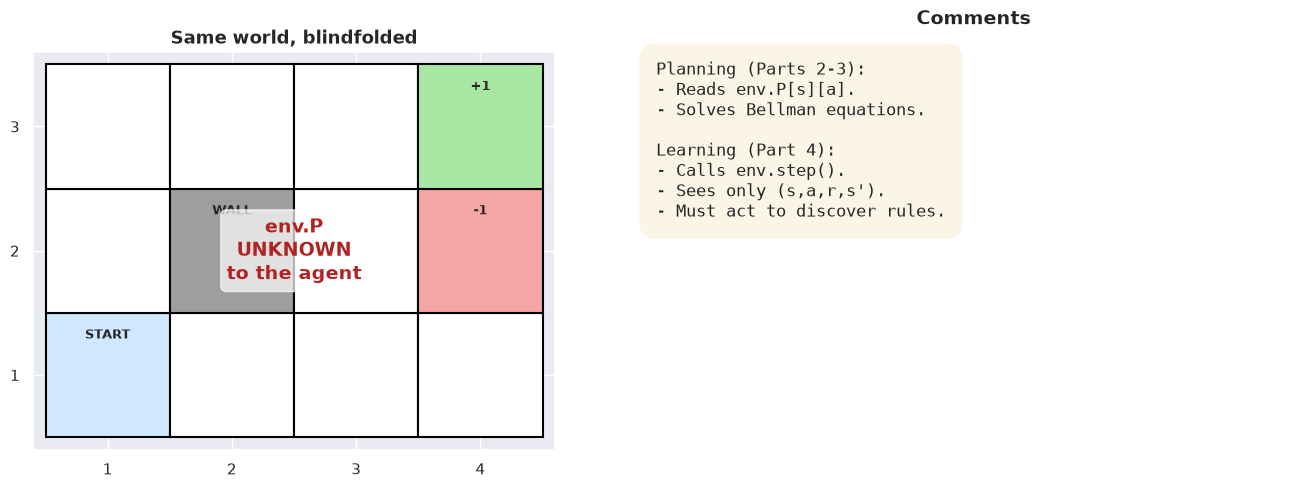

In [33]:
# Contrast planning (reads env.P) with learning (calls env.step()).
utils.cell4_1_planning_vs_learning()

- The transition model is hidden behind the gymnasium API
- The agent discovers the world by interacting with it

## Cell 4.2: The Q-learning update rule

**Goal**
- Introduce the single update that powers Q-learning
- Show how one `env.step()` call produces the TD update tuple

**Description**
- Inputs
  - `alpha`: learning rate
  - `gamma`: discount factor

- Panels
  - the TD update applied to one `env.step()` tuple

In [34]:
# Show how a single env.step() tuple nudges a Q-value.
utils.cell4_2_q_update_rule()

**Guided usage**
- Set `alpha` near 0 vs near 1
  - Observe the TD error measures surprise, the gap between old
    expectation and observed outcome, and no transition probabilities
    are needed to compute it

**Implementation** `utils.cell4_2_q_update_rule()`

In [ ]:
hintros.print_obj_info(utils.cell4_2_q_update_rule)

## Cell 4.3: Exploration vs exploitation with epsilon-greedy

**Goal**
- Show why the agent must sometimes act randomly
- Compare state coverage at low and high exploration rates

**Description**
- Inputs
  - `epsilon`: exploration probability
  - `log(n_episodes)`: training episodes
  - `seed`: random seed

- Panels
  - a visit heatmap of which states the agent has explored

In [35]:
# Compare state coverage under low vs high epsilon using q_learning().
utils.cell4_3_exploration()

**Guided usage**
- Compare `epsilon` low vs high
  - Observe the visit heatmap reveals exactly which states the agent
    has explored: a balance between exploration and exploitation is
    essential

**Implementation** `utils.cell4_3_exploration()`

In [ ]:
hintros.print_obj_info(utils.cell4_3_exploration)

## Cell 4.4: Watching Q-learning learn the optimal policy

**Goal**
- Run full Q-learning and watch the learned policy emerge
- Compare it to the policy value iteration found with full knowledge

**Description**
- Inputs
  - `log(n_episodes)`: training episodes
  - `alpha`: learning rate
  - `epsilon`: exploration probability
  - `seed`: random seed

- Panels
  - the learned policy arrows, and the learning curve of returns over
    episodes

In [36]:
# Train Q-learning via env.step() and compare to the planning optimum.
utils.cell4_4_q_learning_converges()

**Guided usage**
- Raise `log(n_episodes)` to its max
  - Observe the learned arrows converge to the value iteration arrows
    as episodes grow, and returns rise and flatten as the Q-table
    stabilises: the same optimal behaviour emerges from pure
    experience, no model required

**Implementation** `utils.cell4_4_q_learning_converges()`

In [ ]:
hintros.print_obj_info(utils.cell4_4_q_learning_converges)

# Summary: The Mental Model

- A `gymnasium.Env` subclass is an MDP: its `P[s][a]` encodes the
  transition model and its `step()` lets the agent interact without
  reading the model
- When the model is known (planning), `value_iteration()` and
  `policy_iteration()` read `env.P` and compute the optimal policy
  exactly
- When the model is unknown (learning), `q_learning()` calls
  `env.step()` and discovers the optimal policy from experience tuples
- All three methods converge to the same optimal policy on the same
  environment: the difference is whether you plan with the model or
  learn without it
- The gymnasium `GridWorldEnv` produces exactly the same optimal
  utilities and policies as the from-scratch `GridWorld` class